# Lasso Regression Baseline

In [1]:
import os
import sys

# Check if running in Google Colab
if 'google.colab' in sys.modules:
    # Clone your repository if it hasn't been cloned yet
    if not os.path.exists('/content/svi_fema_spatial_graph_modeling'):
        !git clone https://github.com/AnhJoe/svi_fema_spatial_graph_modeling.git

    # Change working directory to the project root
    os.chdir('/content/svi_fema_spatial_graph_modeling')

In [2]:
#| output: false

import sys
from pathlib import Path

# Set to root for src load
root = Path.cwd()
while root != root.parent and not (root / "src").exists():
    root = root.parent

if not (root / "src").exists():
    raise FileNotFoundError("Could not find 'src' folder above current working directory.")

sys.path.insert(0, str(root))
print("Project root:", root)

Project root: c:\Users\joetn\svi_fema_spatial_graph_modeling


In [3]:
# Standard library
import json

# Third-party libraries
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Local imports
from src.lasso import (
    evaluate_regression,
    get_coefficient_table,
    run_lasso_experiment,
    set_seed,
)

# Plot configuration
plt.rcParams.update(
    {
        "font.size": 9,
        "axes.titlesize": 10,
        "axes.labelsize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "legend.title_fontsize": 9,
        "legend.frameon": True,
        "legend.borderpad": 0.3,
    }
)

# Reproducibility
SEED = 42

## Model Motivation

The Lasso (L1-regularized linear) regression serves as a non-neural baseline for predicting county-level disaster assistance outcomes using the log-transformed SVI indicator features. Unlike the MLP and GCN models developed later in this study, Lasso assumes a strictly linear relationship between predictors and the target, and its L1 penalty drives the coefficients of uninformative features toward exactly zero.

This baseline serves two purposes: it establishes a performance floor against which the added complexity of nonlinear and spatial models can be justified, and its sparsity provides a directly interpretable view of which SVI indicators carry the strongest linear association with disaster assistance.

## Model Formulation

Let $X \in \mathbb{R}^{n \times p}$ denote the standardized feature matrix, where $n$ is the number of counties and $p = 15$ is the number of SVI indicator variables after preprocessing and selective log transformation. Let $y \in \mathbb{R}^{n}$ denote the standardized target variable, defined as the log-transformed FEMA Individuals and Households Program assistance amount:

$$
y = \log(1 + \text{FEMA IHP})
$$

Lasso regression estimates a linear coefficient vector $w \in \mathbb{R}^{p}$ and intercept $b$ by minimizing the penalized sum of squared errors

$$
\mathcal{L}(w, b) = \frac{1}{2n}\sum_{i=1}^{n}\left(y_i - (w^\top x_i + b)\right)^2 + \alpha \lVert w \rVert_1
$$

where $\alpha \geq 0$ controls the strength of the $L_1$ penalty. As $\alpha$ increases, more coefficients are driven exactly to zero, yielding an increasingly sparse and interpretable model.

Two target definitions are evaluated in parallel throughout this notebook: the raw log-transformed total assistance, $y = \log(1 + \text{FEMA IHP})$, and a disaster-frequency-normalized version, $y = \log(1 + \text{FEMA IHP} / \text{disaster count})$, which divides total assistance by the number of distinct FEMA-declared disasters in each county before log-transforming.

In [4]:
# Data directories
RAW_DATA_DIR = root / "data" / "raw"
PROCESSED_DATA_DIR = root / "data" / "processed"
ARTIFACT_DIR = root / "data" / "artifacts"

# Do not change row indices beyond this
X_log = pd.read_csv(PROCESSED_DATA_DIR / "X_log.csv")
y_log = pd.read_csv(PROCESSED_DATA_DIR / "y_log.csv")
y_log_normalized = pd.read_csv(PROCESSED_DATA_DIR / "y_log_normalized.csv")
fips = pd.read_csv(PROCESSED_DATA_DIR / "fips.csv")["FIPS"].astype(str).str.zfill(5)

with open(PROCESSED_DATA_DIR / "feature_titles.json") as f:
    feature_titles_log = json.load(f)

feature_names = list(X_log.columns)

In [5]:
# Split log-transformed features and both targets (raw + disaster-frequency-normalized)
# with fips to maintain row indices for downstream models. Both targets share the same
# split since they are derived from the same rows in the same order.

# First split: train vs temp (val + test) = 70/30
Xlog_train, Xlog_temp, ylog_train, ylog_temp, yfreqlog_train, yfreqlog_temp, fips_train, fips_temp = train_test_split(
    X_log,
    y_log,
    y_log_normalized,
    fips,
    test_size=0.30,
    random_state=SEED,
)

# Second split: validation vs test = 15/15
Xlog_val, Xlog_test, ylog_val, ylog_test, yfreqlog_val, yfreqlog_test, fips_val, fips_test = train_test_split(
    Xlog_temp,
    ylog_temp,
    yfreqlog_temp,
    fips_temp,
    test_size=0.50,
    random_state=SEED,
)

split_summary = pd.DataFrame({
    "Dataset": ["Train", "Validation", "Test"],
    "Samples": [Xlog_train.shape[0], Xlog_val.shape[0], Xlog_test.shape[0]],
})

display(split_summary.style.hide(axis="index"))

Dataset,Samples
Train,2198
Validation,471
Test,472


In [6]:
# Scale X_log and both targets on train only, matching preprocessing used for the MLP/GCN pipelines
scaler_Xlog = StandardScaler()
Xlog_train_scaled = scaler_Xlog.fit_transform(Xlog_train)
Xlog_val_scaled = scaler_Xlog.transform(Xlog_val)
Xlog_test_scaled = scaler_Xlog.transform(Xlog_test)

scaler_ylog = StandardScaler()
ylog_train_scaled = scaler_ylog.fit_transform(ylog_train)
ylog_val_scaled = scaler_ylog.transform(ylog_val)
ylog_test_scaled = scaler_ylog.transform(ylog_test)

scaler_yfreqlog = StandardScaler()
yfreqlog_train_scaled = scaler_yfreqlog.fit_transform(yfreqlog_train)
yfreqlog_val_scaled = scaler_yfreqlog.transform(yfreqlog_val)
yfreqlog_test_scaled = scaler_yfreqlog.transform(yfreqlog_test)

# Target definitions evaluated in parallel throughout this notebook
target_definitions = {
    "Raw": {
        "train": ylog_train_scaled, "val": ylog_val_scaled, "test": ylog_test_scaled,
        "scaler": scaler_ylog,
    },
    "Normalized": {
        "train": yfreqlog_train_scaled, "val": yfreqlog_val_scaled, "test": yfreqlog_test_scaled,
        "scaler": scaler_yfreqlog,
    },
}

## Alpha (Regularization Strength) Ablation

Model selection for Lasso reduces to choosing a single hyperparameter: the L1 regularization strength $\alpha$. A grid of candidate values spanning several orders of magnitude is evaluated in one pass on the validation split for both the raw and disaster-frequency-normalized targets, summarized in @tbl-lasso-alpha-ablation. For each target, the configuration with the lowest validation RMSE is carried forward and retrained on the full training set for final test evaluation.

In [7]:
#| label: tbl-lasso-alpha-ablation
#| tbl-cap: Validation-set alpha ablation results for the Lasso baseline, for both the raw and disaster-frequency-normalized targets.

set_seed(SEED)

alpha_grid = [0.0003, 0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1.0, 3.0]

alpha_results = []
for target_name, t in target_definitions.items():
    for alpha in alpha_grid:
        result = run_lasso_experiment(
            X_train=Xlog_train_scaled,
            y_train=t["train"],
            X_eval=Xlog_val_scaled,
            y_eval=t["val"],
            alpha=alpha,
            seed=SEED,
            scaler_y=t["scaler"],
        )
        alpha_results.append({
            "Target": target_name,
            "Alpha": alpha,
            "Non-zero Coefficients": result["n_nonzero_coef"],
            "Validation RMSE": round(result["rmse"], 6),
            "Validation R²": round(result["r2"], 6),
        })

alpha_results_df = pd.DataFrame(alpha_results)
display(alpha_results_df.style.hide(axis="index"))

best_alpha_by_target = (
    alpha_results_df.loc[alpha_results_df.groupby("Target")["Validation RMSE"].idxmin()]
    .set_index("Target")["Alpha"]
    .to_dict()
)
print("Best alpha by target (lowest validation RMSE):", best_alpha_by_target)

Target,Alpha,Non-zero Coefficients,Validation RMSE,Validation R²
Raw,0.000300,15,2.548132,0.271758
Raw,0.001000,15,2.546990,0.272411
Raw,0.003000,15,2.544051,0.274089
Raw,0.010000,14,2.537969,0.277556
Raw,0.030000,9,2.547365,0.272196
Raw,0.100000,4,2.623230,0.228201
Raw,0.300000,1,2.824088,0.105484
Raw,1.000000,0,2.986008,-0.000032
Raw,3.000000,0,2.986008,-0.000032
Normalized,0.000300,15,2.476052,0.276615


Best alpha by target (lowest validation RMSE): {'Normalized': 0.01, 'Raw': 0.01}


## Lasso Experimental Results

The alpha ablation identifies **alpha = 0.01** as the best-performing regularization strength on the validation split for both targets, retaining 14 of the 15 log-transformed SVI indicators with non-zero coefficients. Very light regularization retains all features but does not improve validation RMSE, while stronger regularization progressively zeroes out coefficients and degrades performance. At alpha = 1.0 both models collapse to predicting the training mean (R² = 0). Each target's best configuration is retrained on the full training set and evaluated once on the held-out test set, shown in @tbl-lasso-test-evaluation.

The raw target reaches **test RMSE = 2.56** and **R² = 0.303**; the normalized target reaches **test RMSE = 2.50** and **R² = 0.302**. The two targets are on different scales (the normalized target compresses multi-disaster counties toward a per-event value), so their RMSE values are not directly comparable, but R² is scale-invariant and nearly identical between them. Normalizing by disaster frequency therefore explains about the same share of variance as the raw total, roughly **30%**, consistent with most counties in this sample experiencing exactly one declared disaster. The Lasso coefficients, shown in @fig-lasso-coefficients, remain useful for interpretation. Multi-unit housing (log), single-parent households, and minority population share carry the largest standardized weights for the raw target, broadly consistent with the socioeconomic and housing themes emphasized elsewhere in the SVI framework.

In [8]:
#| label: tbl-lasso-test-evaluation
#| tbl-cap: Held-out test-set performance for the final Lasso configuration, for both the raw and disaster-frequency-normalized targets.

set_seed(SEED)

final_lasso_results_list = []
final_lasso_models = {}

for target_name, t in target_definitions.items():
    alpha = best_alpha_by_target[target_name]

    result = run_lasso_experiment(
        X_train=Xlog_train_scaled,
        y_train=t["train"],
        X_eval=Xlog_test_scaled,
        y_eval=t["test"],
        alpha=alpha,
        seed=SEED,
        scaler_y=t["scaler"],
    )

    final_lasso_models[target_name] = result["model"]
    final_lasso_results_list.append({
        "Model": "Lasso",
        "Target": target_name,
        "Feature Pipeline": "Log-Transformed Features",
        "Alpha": alpha,
        "Non-zero Coefficients": result["n_nonzero_coef"],
        "Test RMSE": round(result["rmse"], 6),
        "Test R²": round(result["r2"], 6),
    })

final_lasso_results = pd.DataFrame(final_lasso_results_list)
display(final_lasso_results.style.hide(axis="index"))

Model,Target,Feature Pipeline,Alpha,Non-zero Coefficients,Test RMSE,Test R²
Lasso,Raw,Log-Transformed Features,0.010000,14,2.555675,0.303201
Lasso,Normalized,Log-Transformed Features,0.010000,14,2.496074,0.302100


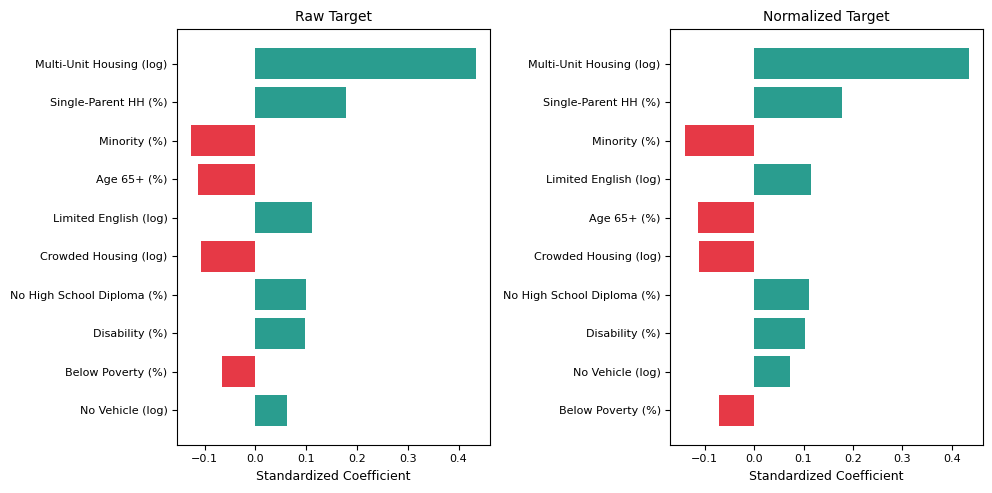

In [9]:
#| label: fig-lasso-coefficients
#| fig-cap: Top standardized Lasso coefficients (by absolute magnitude) for the raw and disaster-frequency-normalized targets.

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

coef_tables = {}
for ax, (target_name, model) in zip(axes, final_lasso_models.items()):
    coef_table = get_coefficient_table(model, feature_names)
    coef_table["Feature Label"] = coef_table["Feature"].map(feature_titles_log).fillna(coef_table["Feature"])
    coef_tables[target_name] = coef_table

    top_coef = coef_table.head(10).iloc[::-1]
    colors = ["#2a9d8f" if c >= 0 else "#e63946" for c in top_coef["Coefficient"]]
    ax.barh(top_coef["Feature Label"], top_coef["Coefficient"], color=colors)
    ax.set_xlabel("Standardized Coefficient")
    ax.set_title(f"{target_name} Target")

plt.tight_layout()
plt.show()

In [10]:
#| output: false

# Ensure the output directories exist
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# Save final artifacts for MLP/GCN/GAT comparisons (both targets)
final_lasso_results.to_csv(ARTIFACT_DIR / "final_lasso_results.csv", index=False)

for target_name, coef_table in coef_tables.items():
    suffix = target_name.lower()
    coef_table.to_csv(ARTIFACT_DIR / f"final_lasso_coefficients_{suffix}.csv", index=False)
    joblib.dump(final_lasso_models[target_name], ARTIFACT_DIR / f"final_lasso_model_{suffix}.pkl")

## Summary of Findings

As a linear baseline, Lasso regression explains roughly **30% of the variance** in county-level FEMA IHP assistance using only the 15 SVI indicators, whether the target is the raw multi-year total or the disaster-frequency-normalized version. The L1 penalty narrows the feature set to a small number of consistently informative predictors, with housing structure, family composition, minority status, and English proficiency emerging as the strongest linear signals.

That normalizing by disaster count barely changes R² is itself informative: it suggests the modest explanatory power of the SVI indicators is not primarily an artifact of some counties simply having more disasters than others, at least not in a way a linear model can exploit. That a purely linear, non-spatial model leaves the majority of the variance (roughly 70%) unexplained under either target formulation motivates two directions worth testing directly rather than assuming. First, whether the relationship between vulnerability indicators and disaster assistance is meaningfully **nonlinear**, which a more flexible model such as a multilayer perceptron (MLP) can evaluate. Second, whether **geographic proximity** carries predictive signal beyond what county-level indicators alone provide, which a graph-based model such as a GCN can evaluate. This Lasso baseline therefore establishes the linear performance floor, under both target formulations, against which the added complexity of nonlinear and spatial models should be justified.